# Desafio 3: Modelo de lenguaje con tokenizacion por caracteres
## Alumno: Maxim Dorogov

### Consigna
- Seleccionar un corpus de texto sobre el cual entrenar el modelo de lenguaje.\
- Realizar el pre-procesamiento adecuado para tokenizar el corpus, estructurar el dataset y separar entre datos de entrenamiento y validación.
- Proponer arquitecturas de redes neuronales basadas en unidades recurrentes para implementar un modelo de lenguaje.
- Con el o los modelos que consideren adecuados, generar nuevas secuencias a partir de secuencias de contexto con las estrategias de greedy search y beam search determístico y estocástico. En este último caso observar el efecto de la temperatura en la generación de secuencias.

### Sugerencias
- Durante el entrenamiento, guiarse por el descenso de la perplejidad en los datos de validación para finalizar el entrenamiento. Para ello se provee un callback.
- Explorar utilizar SimpleRNN (celda de Elman), LSTM y GRU.
- rmsprop es el optimizador recomendado para la buena convergencia. No obstante se pueden explorar otros.

In [200]:
import os
from typing import Literal, List, Optional, Callable

import torch
from torch.utils.data import DataLoader, TensorDataset
import torch.nn.functional as F
from torchinfo import summary
from torch import nn

import numpy as np
import gradio as gr
from tqdm import tqdm
from matplotlib import pyplot as plt

## Desarrollo

### Carga del dataset y tokenizacion

El dataset a utilizar es [Lovecraft Fiction](https://www.kaggle.com/datasets/bennijesus/lovecraft-fiction?resource=download), que contiene relatos, en idioma ingles, del autor H.P. Lovecraft.

In [201]:
# levantamos el archivo concat.txt el cual contiene todos los relatos concatenados.

DATA_PATH = '../desafio_2/data/concat.txt'
with open(DATA_PATH, 'r', encoding='utf-8') as f:
    corpus = f.read()
# Elimino caracteres de salto de linea, retorno de carro y tabulacion
corpus = corpus.replace('\n', '')
corpus = corpus.replace('\r', '')
corpus = corpus.replace('\t', '')

print(f'Corpus length: {len(corpus)} characters')
print(f'Corpus sample: {corpus[:300]}')

Corpus length: 3851235 characters
Corpus sample: High up, crowning the grassy summit of a swelling mound whose sides are wooded near the basewith the gnarled trees of the primeval forest, stands the old chateau of my ancestors. For centuriesits lofty battlements have frowned down upon the wild and rugged countryside about, servingas a home and str


In [202]:
# Construimos vocabulario de caracteres y tokens

corpus = corpus.lower()
chars_vocab = set(corpus)

char2idx = {k: v for v,k in enumerate(chars_vocab)}  
idx2char = {v: k for k,v in char2idx.items()}

# Tokenizamos

tokenized_text = [char2idx[ch] for ch in corpus]
print(tokenized_text[:20])
print([idx2char[c] for c in tokenized_text[:20]])
print(f'Vocabulary size: {len(chars_vocab)} characters')

[23, 14, 92, 23, 56, 41, 89, 20, 56, 33, 84, 73, 34, 68, 14, 68, 92, 56, 8, 23]
['h', 'i', 'g', 'h', ' ', 'u', 'p', ',', ' ', 'c', 'r', 'o', 'w', 'n', 'i', 'n', 'g', ' ', 't', 'h']
Vocabulary size: 97 characters


### Fraccionamiento en secuencias

In [203]:
CONTEXT_WINDOW_SIZE = 100

# spliteamos en oraciones de largo CONTEXT_WINDOW_SIZE
tokenized_sentences = [
    tokenized_text[init:init + CONTEXT_WINDOW_SIZE] for
    init in range(len(tokenized_text) - CONTEXT_WINDOW_SIZE + 1)]
X = np.array(list(tokenized_sentences)[:-1])
y = np.array(list(tokenized_sentences)[1:])

# Nos queda un array de shape (N, CONTEXT_WINDOW_SIZE) donde N es la cantidad 
# de oraciones que se pudieron formar
print(f'X shape: {X.shape}, y shape: {y.shape}')

X shape: (3851135, 100), y shape: (3851135, 100)


### Arquitecturas de las redes neuronales a utilizar

Se van a evaluar las siguientes arquitecturas:
1. SimpleRNN
2. LSTM
3. GRU

In [204]:
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using {device}")

Using cuda


In [262]:
class SimpleRNN(nn.Module):
    """
    Modelo de lenguaje basado en RNN simple.
    """
    def __init__(
        self, 
        vocab_size: int, 
        hidden_size: int = 128, 
        embed_dim: int = 16,
        rnn_layers: int = 2
    ):
        """
        Parameters
        ----------
        vocab_size : int
            Unique tokens in vocabulary.
        hidden_size : int
            Size of the RNN hidden state. Default is 128.
        embed_dim : int
            Dimension of the token embeddings. Default is 16.
        rnn_layers : int
            Number of RNN layers. Default is 2.
        """
        super().__init__()
        self.vocab_size = vocab_size

        self.embedding = nn.Embedding(
            num_embeddings=vocab_size, embedding_dim=embed_dim)
        self.rnn = nn.RNN(
            input_size=embed_dim,
            hidden_size=hidden_size,
            dropout=0.1,
            num_layers=rnn_layers,
            batch_first=True
        )
        self.fc = nn.Linear(hidden_size, vocab_size)

    def forward(self, x):
        x = x.long()
        x = self.embedding(x)                
        out, _ = self.rnn(x)
        logits = self.fc(out)                     
        return logits                          

class SimpleLSTM(nn.Module):
    """
    Modelo de lenguaje basado en LSTM.
    """
    def __init__(
        self, 
        vocab_size: int, 
        hidden_size: int = 128, 
        embed_dim: int = 16,
        rnn_layers: int = 2
    ):
        """
        Parameters
        ----------
        vocab_size : int
            Unique tokens in vocabulary.
        hidden_size : int
            Size of the LSTM hidden state. Default is 200.
        embed_dim : int
            Dimension of the token embeddings. Default is 16.
        rnn_layers : int
            Number of stacked LSTM layers. Default is 2.
        """
        super().__init__()
        self.vocab_size = vocab_size

        self.embedding = nn.Embedding(
            num_embeddings=vocab_size, embedding_dim=embed_dim)
        self.lstm = nn.LSTM(
            input_size=embed_dim,
            hidden_size=hidden_size,
            num_layers=rnn_layers,
            dropout=0.1,
            batch_first=True
        )
        self.fc = nn.Linear(hidden_size, vocab_size)

    def forward(self, x):
        
        x = x.long()
        x = self.embedding(x)

        x, (h_n, c_n) = self.lstm(x)

        logits = self.fc(x)
        return logits


class SimpleGRU(nn.Module):
    """
    Modelo de lenguaje basado en GRU.
    """
    def __init__(
        self, 
        vocab_size: int, 
        hidden_size: int = 128, 
        embed_dim: int = 16,
        rnn_layers: int = 2
    ):
        """
        Parameters
        ----------
        vocab_size : int
            Unique tokens in vocabulary.
        hidden_size : int
            Size of the LSTM hidden state. Default is 200.
        embed_dim : int
            Dimension of the token embeddings. Default is 16.
        rnn_layers : int
            Number of stacked LSTM layers. Default is 2.
        """
        super().__init__()
        self.vocab_size = vocab_size

        self.embedding = nn.Embedding(
            num_embeddings=vocab_size, embedding_dim=embed_dim)
        self.gru = nn.GRU(
            input_size=embed_dim,
            hidden_size=hidden_size,
            num_layers=rnn_layers,
            dropout=0.1,
            batch_first=True
        )
        self.fc = nn.Linear(hidden_size, vocab_size)

    def forward(self, x):
        
        x = x.long()
        x = self.embedding(x)

        x, _ = self.gru(x)

        logits = self.fc(x)
        return logits

In [206]:
model = SimpleRNN(vocab_size=len(chars_vocab)).to('cuda')

print('--- Torchinfo summary: ---')
print(summary(model, input_size=(1, 100)))

model = SimpleLSTM(vocab_size=len(chars_vocab)).to('cuda')
print('--- Torchinfo summary: ---')
print(summary(model, input_size=(1, 100)))

--- Torchinfo summary: ---
Layer (type:depth-idx)                   Output Shape              Param #
SimpleRNN                                [1, 100, 97]              --
├─Embedding: 1-1                         [1, 100, 16]              1,552
├─RNN: 1-2                               [1, 100, 128]             51,712
├─Linear: 1-3                            [1, 100, 97]              12,513
Total params: 65,777
Trainable params: 65,777
Non-trainable params: 0
Total mult-adds (M): 5.19
Input size (MB): 0.00
Forward/backward pass size (MB): 0.19
Params size (MB): 0.26
Estimated Total Size (MB): 0.46
--- Torchinfo summary: ---
Layer (type:depth-idx)                   Output Shape              Param #
SimpleLSTM                               [1, 100, 97]              --
├─Embedding: 1-1                         [1, 100, 16]              1,552
├─LSTM: 1-2                              [1, 100, 128]             206,848
├─Linear: 1-3                            [1, 100, 97]              12,513
To

In [207]:
print('--- Torchinfo summary: ---')
print(summary(model, input_size=(1, 100)))

--- Torchinfo summary: ---
Layer (type:depth-idx)                   Output Shape              Param #
SimpleLSTM                               [1, 100, 97]              --
├─Embedding: 1-1                         [1, 100, 16]              1,552
├─LSTM: 1-2                              [1, 100, 128]             206,848
├─Linear: 1-3                            [1, 100, 97]              12,513
Total params: 220,913
Trainable params: 220,913
Non-trainable params: 0
Total mult-adds (M): 20.70
Input size (MB): 0.00
Forward/backward pass size (MB): 0.19
Params size (MB): 0.88
Estimated Total Size (MB): 1.08


### Entrenamiento

Se realizara un split 80/20 para train y validation mediante un muestreo aleatorio
entre todos los chuncks de tamanio CONTEXT_WINDOW_SIZE. Esto se hace para obtener
secuencias de entrenamiento provenientes de distintas partes del corpus.

In [208]:
BATCH_SIZE = 256
VAL_SPLIT = 0.2

dataset = TensorDataset(
    torch.tensor(X, dtype=torch.long), 
    torch.tensor(y, dtype=torch.long))

train_dataset, val_dataset = torch.utils.data.random_split(
    dataset, [1 - VAL_SPLIT, VAL_SPLIT])

train_dataloader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_dataloader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)

In [ ]:
def perplexity(loss_value: float) -> float:
    try:
        perplexity = np.exp(loss_value)
    except OverflowError:
        perplexity = float('inf')
    return perplexity

def evaluate(model, data_loader, loss_fn) -> tuple[float, float]:
    model.eval()
    total_loss = 0
    with torch.no_grad():
        for input, target in tqdm(data_loader, desc="Validation"):
            input, target = input.to(device), target.to(device)
            logits = model(input)
            loss = loss_fn(logits.transpose(1, 2), target)
            total_loss += loss.item()
    avg_loss = total_loss / len(data_loader)
    ppl = perplexity(avg_loss)
    return avg_loss, ppl

def train(
    model: nn.Module, 
    output_model_path: str,
    optimizer: torch.optim.Optimizer,
    loss_fn: nn.Module,
    epochs: int = 10,
    max_patience: int = 10,
    lr_scheduler: Optional[torch.optim.lr_scheduler.LRScheduler] = None,
    metrics: Optional[Callable] = None):

    """
    Trains the model and tracks training loss and perplexity. Optionally uses
    a learning rate scheduler and evaluation metrics function.
    Parameters
    ----------
    model : nn.Module
        The neural network model to be trained.
    output_model_path : str
        Directory path to save the best model.
    optimizer : torch.optim.Optimizer
        The optimizer used for training.
    loss_fn : nn.Module
        The loss function used for training.
    epochs : int
        Number of training epochs.
    max_patience : int
        Number of epochs with no improvement after which training will be stopped.
    lr_scheduler : Optional[torch.optim.lr_scheduler.LRScheduler], optional
        Learning rate scheduler to adjust the learning rate during training,
        by default None.
    metrics : Optional[Callable], optional
        A callable function to compute evaluation metrics, by default None.
    Returns
    -------
    Tuple[List[float], List[float], List[float], List[float]]
        Returns lists of training loss, validation loss, training perplexity,
        and validation perplexity for each epoch.
    """
    train_loss_avg = list()
    val_loss_avg = list()
    train_ppl = list()
    val_ppl = list()
    best_val_ppl = np.inf

    os.makedirs(os.path.dirname(output_model_path), exist_ok=True)

    for epoch in range(epochs):
        model.train()
        epoch_loss = 0

        for input, target in tqdm(
            train_dataloader, desc=f"Training: Epoch {epoch+1}/{epochs}"):

            input, target = input.to(device), target.to(device)
            optimizer.zero_grad()
            logits = model(input)

            loss = loss_fn(logits.transpose(1, 2), target)
            loss.backward()
            optimizer.step()
            epoch_loss += loss.item()

        # training metrics
        train_loss_avg.append(epoch_loss / len(train_dataloader))
        train_ppl.append(perplexity(loss_value=train_loss_avg[-1]))

        if lr_scheduler is not None:
            # learning rate scheduler step monitoreando la loss de train
            lr_scheduler.step(train_loss_avg[-1])

        # evaluation metrics
        if metrics is not None:
            eval_loss, eval_ppl = metrics(model, val_dataloader, loss_fn)
            val_loss_avg.append(eval_loss)
            val_ppl.append(eval_ppl)

        # save model if metric improves:
        if epoch == 0 or eval_ppl < best_val_ppl:
            patience = 0
            print(
                f'Val ppl improved from {best_val_ppl if epoch > 0 else "inf"} to {eval_ppl}, '
                f'saving model at epoch {epoch+1}')
            torch.save(
                model.state_dict(), 
                f"{output_model_path}/{model.__class__.__name__}_best.pth")
            best_val_ppl = eval_ppl
        else:
            patience += 1
            if patience >= max_patience:
                print(f'Early stopping at epoch {epoch+1}')
                break

        print(f"train loss: {train_loss_avg[-1]:.3f}",
            f" - val loss: {val_loss_avg[-1]:.3f}",
            f" - train ppl: {train_ppl[-1]:.4f} - val ppl: {val_ppl[-1]:.4f}")

    return train_loss_avg, val_loss_avg, train_ppl, val_ppl

#### SimpleRNN Training

In [215]:
# --- training loop ---
EPOCHS = 50

model = SimpleRNN(
    vocab_size=len(chars_vocab), 
    embed_dim=int(np.sqrt(len(chars_vocab)))
).to('cuda')

optimizer = torch.optim.RMSprop(model.parameters(), lr=0.005)
loss_fn = nn.CrossEntropyLoss()
lr_scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, patience=5, mode='max', threshold=0.001)

train_loss_avg, val_loss_avg, train_ppl, val_ppl = train(
    model=model,
    epochs=EPOCHS,
    max_patience=5,
    output_model_path='./training_results',
    optimizer=optimizer,
    loss_fn=loss_fn,
    lr_scheduler=lr_scheduler,
    metrics=evaluate)

Validation: 100%|██████████| 3009/3009 [00:05<00:00, 512.87it/s]


Val ppl improved from inf to 6.033069163904453, saving model at epoch 1
train loss: 1.954  - val loss: 1.797  - train ppl: 7.0564 - val ppl: 6.0331


Validation: 100%|██████████| 3009/3009 [00:05<00:00, 504.59it/s]


Val ppl improved from 6.033069163904453 to 5.915760112932323, saving model at epoch 2
train loss: 1.834  - val loss: 1.778  - train ppl: 6.2580 - val ppl: 5.9158


Validation: 100%|██████████| 3009/3009 [00:05<00:00, 508.59it/s]


...

train loss: 1.761  - val loss: 1.712  - train ppl: 5.8202 - val ppl: 5.5386


Validation: 100%|██████████| 3009/3009 [00:06<00:00, 500.96it/s]


train loss: 1.761  - val loss: 1.712  - train ppl: 5.8201 - val ppl: 5.5386


Validation: 100%|██████████| 3009/3009 [00:05<00:00, 509.96it/s]

Early stopping at epoch 37


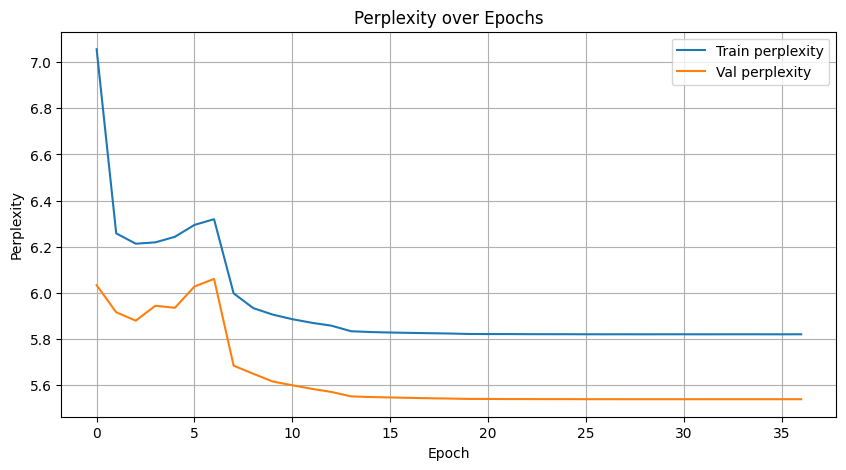

In [219]:
plt.figure(figsize=(10, 5))
plt.plot(train_ppl)
plt.plot(val_ppl)
plt.title('Perplexity over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Perplexity')
plt.grid()
plt.legend(['Train perplexity', 'Val perplexity'])
plt.show()

#### SimpleLSTM Training

In [250]:
model = SimpleLSTM(
    vocab_size=len(chars_vocab), 
    embed_dim=int(np.sqrt(len(chars_vocab)))
).to('cuda')

optimizer = torch.optim.RMSprop(model.parameters(), lr=0.005)
loss_fn = nn.CrossEntropyLoss()
lr_scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, patience=5, mode='max', threshold=0.001)

train_loss_avg, val_loss_avg, train_ppl, val_ppl = train(
    model=model,
    epochs=EPOCHS,
    max_patience=5,
    output_model_path='./training_results',
    optimizer=optimizer,
    loss_fn=loss_fn,
    lr_scheduler=lr_scheduler,
    metrics=evaluate)

Validation: 100%|██████████| 3009/3009 [00:15<00:00, 199.45it/s]


Val ppl improved from inf to 3.7188045548189526, saving model at epoch 1
train loss: 1.376  - val loss: 1.313  - train ppl: 3.9586 - val ppl: 3.7188


Validation: 100%|██████████| 3009/3009 [00:17<00:00, 176.75it/s]


Val ppl improved from 3.7188045548189526 to 3.689395711896085, saving model at epoch 2
train loss: 1.307  - val loss: 1.305  - train ppl: 3.6946 - val ppl: 3.6894


Validation: 100%|██████████| 3009/3009 [00:15<00:00, 198.84it/s]


...

train loss: 1.227  - val loss: 1.228  - train ppl: 3.4107 - val ppl: 3.4160


Validation: 100%|██████████| 3009/3009 [00:14<00:00, 201.55it/s]


train loss: 1.227  - val loss: 1.228  - train ppl: 3.4107 - val ppl: 3.4160


Validation: 100%|██████████| 3009/3009 [00:14<00:00, 201.48it/s]

Early stopping at epoch 44


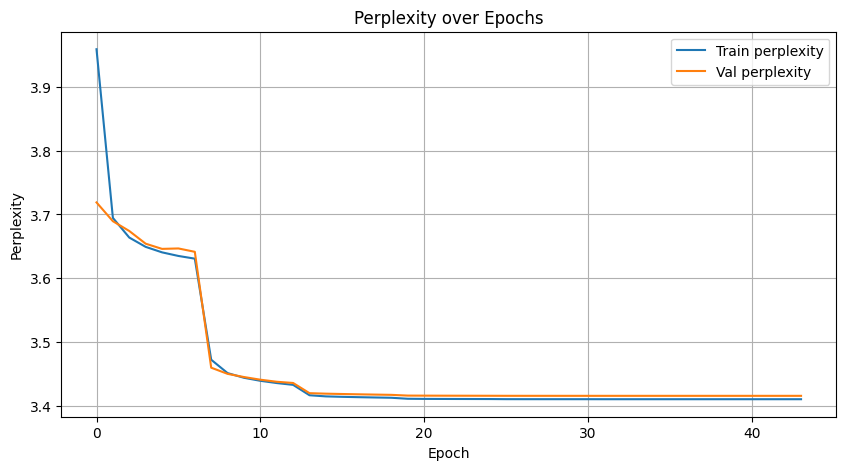

In [260]:
plt.figure(figsize=(10, 5))
plt.plot(train_ppl)
plt.plot(val_ppl)
plt.title('Perplexity over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Perplexity')
plt.grid()
plt.legend(['Train perplexity', 'Val perplexity'])
plt.show()

#### SimpleGRU Training

In [265]:
model = SimpleGRU(
    vocab_size=len(chars_vocab), 
    embed_dim=int(np.sqrt(len(chars_vocab)))
).to('cuda')

optimizer = torch.optim.RMSprop(model.parameters(), lr=0.005)
loss_fn = nn.CrossEntropyLoss()
lr_scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, patience=5, mode='max', threshold=0.001)

train_loss_avg, val_loss_avg, train_ppl, val_ppl = train(
    model=model,
    epochs=EPOCHS,
    max_patience=10,
    output_model_path='./training_results',
    optimizer=optimizer,
    loss_fn=loss_fn,
    lr_scheduler=lr_scheduler,
    metrics=evaluate)

Validation: 100%|██████████| 3009/3009 [00:11<00:00, 266.60it/s]


Val ppl improved from inf to 4.081654816349537, saving model at epoch 1
train loss: 1.529  - val loss: 1.407  - train ppl: 4.6157 - val ppl: 4.0817


Validation: 100%|██████████| 3009/3009 [00:10<00:00, 280.43it/s]


Val ppl improved from 4.081654816349537 to 3.993506566805244, saving model at epoch 2
train loss: 1.441  - val loss: 1.385  - train ppl: 4.2245 - val ppl: 3.9935


Validation: 100%|██████████| 3009/3009 [00:12<00:00, 237.82it/s]


...

train loss: 1.376  - val loss: 1.327  - train ppl: 3.9575 - val ppl: 3.7679


Validation: 100%|██████████| 3009/3009 [00:12<00:00, 234.59it/s]


Val ppl improved from 3.7678576575662923 to 3.767857600543857, saving model at epoch 49
train loss: 1.376  - val loss: 1.327  - train ppl: 3.9576 - val ppl: 3.7679


Validation: 100%|██████████| 3009/3009 [00:10<00:00, 283.64it/s]

Val ppl improved from 3.767857600543857 to 3.767857572779007, saving model at epoch 50
train loss: 1.376  - val loss: 1.327  - train ppl: 3.9575 - val ppl: 3.7679


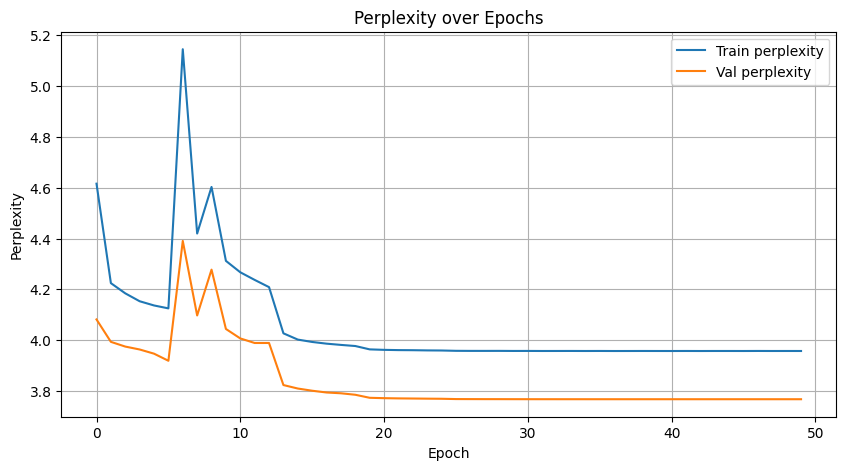

In [266]:
plt.figure(figsize=(10, 5))
plt.plot(train_ppl)
plt.plot(val_ppl)
plt.title('Perplexity over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Perplexity')
plt.grid()
plt.legend(['Train perplexity', 'Val perplexity'])
plt.show()

#### Conclusiones parciales

Se observa que el modelo basado en LSTM es el que mas parametros tiene y es el que mas tiempo demora en entrenar. El modelo basado en GRU se encuentra en un punto intermedio entre SimpleRNN y SimpleLSTM en cuanto a cantidad de parametros y tiempo de entrenamiento. Esto es consistente con lo estudiado durante las clases teoricas ya que GRU es una version simplificada de LSTM que, entre otras cosas, combina los gates de input y forget en una sola reduciendo la cantidad de parametros. En cuanto a la perplejidad del modelo final, el modelo basado en RNNs queda en el ultimo lugar, mientras que los modelos basados en LSTM y GRU tienen un desempeño similar, con una leve ventaja para el modelo basado en LSTM. Como dato adicional, setuvo que aumentarar el valor de max_patience para el entrenamiento de SimpleGRU de 5 a 10 epochs para evitar un early stopping prematuro.

## Generacion de secuencias

Se van a presentar resultados de generacion de secuencias partiendo de un texto semilla:

1. compuesto por un unico caracter
1. compuesto por una secuencia de palabras

Se van a generar secuencias con los tres modelos entrenados utilizando las mismas semillas utilizando metodos de generacion greedy y beam search (deterministico y estocastico).

In [220]:
def inference_greedy(model: nn.Module, seed_text: str, n_chars: int) -> str:
    """
    Generates a text sequence from a seed text using
    a trained language model and a greedy sampling strategy.

    Parameters
    ----------
    model : nn.Module
        Trained language model.
    seed_text : str
        Seed text to start generation.
    n_chars : int
        Number of characters to generate.
    
    Returns
    -------
    str
        Generated text.
    """
    model.eval()
    device = next(model.parameters()).device # reads model device
    output_text = seed_text

    for _ in range(n_chars):
        encoded = [char2idx.get(ch) for ch in output_text.lower()]

        # to tensor (batch=1, seq_len=max_length, 1)
        x = torch.tensor(encoded, dtype=torch.long).unsqueeze(0).to(device)

        # --- Forward ---
        with torch.no_grad():
            logits = model(x)
            probs = F.softmax(logits[0, -1, :], dim=-1)
            y_hat = torch.argmax(probs).item()

        # convertir a caracter
        out_char = idx2char[y_hat]
        output_text += out_char

    return output_text

def select_candidates(
    probs: List[np.ndarray], 
    top_k: int, 
    vocab_size: int, 
    history_probs: List[float], 
    history_tokens: List[np.ndarray],
    mode: Literal['det', 'sto'] = 'det', 
    temp: float = 1.0):
    """
    preds: List[np.ndarray]
        Model predictions (probabilidades) of shape vocab_size for each beam
        [[beam_1_probs], [beam_2_probs], ...]
    top_k: int
        Number of candidates to select
    vocab_size: int
        Size of the vocabulary
    history_probs: List[float]
        List of accumulated log-probs so far
    history_tokens: List[np.ndarray]
        List of token sequences so far
    """

    # Compute log prob over the flattened list of lists of predictions
    acc_log_probs = list()
    for idx, pred in enumerate(probs):
        log_probs = np.log(pred + 1e-10)
        acc_log_probs.extend(log_probs + history_probs[idx])
    
    acc_log_probs = np.array(acc_log_probs)

    if mode == 'det':
        # select the top_k log_probs (closest to 0) and accumulate
        topk_idxes = np.argsort(acc_log_probs)[::-1][:top_k]
    elif mode == 'sto':

        safe_temp = max(temp, 1e-6)
        shifted = acc_log_probs - acc_log_probs.max()
        scaled = np.exp(shifted / safe_temp)
        total = scaled.sum()
        if not np.isfinite(total) or total <= 0:
            scaled = np.full_like(scaled, 1.0 / scaled.size)
        else:
            scaled = scaled / total
        topk_idxes = np.random.choice(
            np.arange(acc_log_probs.shape[0]), top_k, p=scaled)

    new_history_tokens = np.concatenate(
        (np.array(history_tokens)[topk_idxes // vocab_size],
         np.array([topk_idxes % vocab_size]).T),
        axis=1)

    return acc_log_probs[topk_idxes.astype(int)], new_history_tokens

def inference_beamsearch(
        model: nn.Module,
        input_text: str,
        n_chars: int,
        top_k: int = 3,
        temp: float = 1.0,
        mode: Literal['det', 'sto'] = 'det'
    ):
    """
    Generates a text sequence from a seed text using a trained language model 
    and a beam search sampling strategy.
    """
    model.eval()
    device = next(model.parameters()).device

    encoded = [char2idx.get(ch) for ch in input_text.lower()]
    x = torch.tensor(encoded, dtype=torch.long).unsqueeze(0).to(device)

    with torch.no_grad():
        logits = model(x)
        preds = F.softmax(logits[0, -1, :], dim=-1).cpu().numpy()

    vocab_size = preds.shape[0]

    # initial probabilities
    accum_probs = [0] * top_k # log prob acumuladed per each beam
    history_tokens = [encoded] * top_k

    # select initial candidates
    accum_probs, history_tokens = select_candidates(
        probs=[preds],
        top_k=top_k,
        vocab_size=vocab_size,
        history_probs=accum_probs,
        history_tokens=history_tokens,
        temp=temp,
        mode=mode)

    #loop beam search
    for _ in range(n_chars):
        preds = []
        # loop over each beam
        for input in history_tokens:
            x = torch.tensor(input, dtype=torch.long).unsqueeze(0).to(device)
            with torch.no_grad():
                logits = model(x)
                y_hat = F.softmax(logits[0, -1, :], dim=-1).cpu().numpy()
            preds.append(y_hat)

        accum_probs, history_tokens = select_candidates(
            probs=preds,
            top_k=top_k,
            vocab_size=vocab_size,
            history_probs=accum_probs,
            history_tokens=history_tokens,
            temp=temp,
            mode=mode)

        # Return the top-k most probable sequences and their log probabilities
        # convert secuences to chars

        text_secs = [
            ''.join([idx2char[t] for t in tokens]) for tokens in history_tokens]

    return accum_probs, text_secs


In [272]:
# Leemos todos los modelos entrenados

model_rnn = SimpleRNN(
    vocab_size=len(chars_vocab), 
    embed_dim=int(np.sqrt(len(chars_vocab)))
).to('cuda')
model_rnn.load_state_dict(torch.load(
    './training_results/SimpleRNN_best.pth', map_location='cuda'))

model_lstm = SimpleLSTM(
    vocab_size=len(chars_vocab), 
    embed_dim=int(np.sqrt(len(chars_vocab)))
).to('cuda')
model_lstm.load_state_dict(torch.load(
    './training_results/SimpleLSTM_best.pth', map_location='cuda'))

model_gru = SimpleGRU(
    vocab_size=len(chars_vocab), 
    embed_dim=int(np.sqrt(len(chars_vocab)))
).to('cuda')
model_gru.load_state_dict(torch.load(
    './training_results/SimpleGRU_best.pth', map_location='cuda'))

<All keys matched successfully>

In [282]:
SEED_CHAR = "sc"
SEED_TEXT = "The abyss was "
SEC_LEN = 150


for model in [model_rnn, model_lstm, model_gru]:

    print(f'--- Secuences gerated with {model.__class__.__name__} ---\n')
    print('--- Greedy ---\n')
    print("Seed char:", SEED_CHAR)
    print(inference_greedy(model, SEED_CHAR, n_chars=SEC_LEN), '\n')
    print("Seed text:", SEED_TEXT)
    print(inference_greedy(model, SEED_TEXT, n_chars=SEC_LEN), '\n')

    print('--- Beam Search Deterministic ---\n')
    print("Seed char:", SEED_CHAR)
    log_probs, text_seqs = inference_beamsearch(
        model_lstm, SEED_CHAR, n_chars=SEC_LEN, top_k=1, mode='det')

    print(f'Log probability: {log_probs[0]:.2f},\n Generated text: {text_seqs[0]}\n')
    print("Seed text:", SEED_TEXT)
    log_probs, text_seqs = inference_beamsearch(
        model_lstm, SEED_TEXT, n_chars=SEC_LEN, top_k=1, mode='det')
    print(f'Log probability: {log_probs[0]:.2f},\n Generated text: {text_seqs[0]}\n')

    print('--- Beam Search Stochastic --- \n')
    log_probs, text_seqs = inference_beamsearch(
        model_lstm, SEED_CHAR, n_chars=SEC_LEN, top_k=2, mode='sto', temp=0.7)
    log_probs, text_seqs = inference_beamsearch(
        model_lstm, SEED_TEXT, n_chars=SEC_LEN, top_k=2, mode='sto', temp=0.95)


--- Secuences gerated with SimpleRNN ---

--- Greedy ---

Seed char: sc
scent the strange the strange the strange the strange the strange the strange the strange the strange the strange the strange the strange the strange th 

Seed text: The abyss was 
The abyss was the strange the strange the strange the strange the strange the strange the strange the strange the strange the strange the strange the strange the st 

--- Beam Search Deterministic ---

Seed char: sc
Log probability: -109.18,
 Generated text: scriptions of the strange strange stone walls and the strange strange stone walls and the strange strange stone walls and the strange strange stone walls

Seed text: The abyss was 
Log probability: -109.63,
 Generated text: the abyss was still an instant i had seen in the strange strange stone walls and the strange strange stone walls and the strange strange stone walls and the strange 

--- Beam Search Stochastic --- 

--- Secuences gerated with SimpleLSTM ---

--- Greedy ---

Seed 